In [1]:
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from datasets import load_dataset
from PIL import Image

In [19]:
class FOMODataset(Dataset):
    def __init__(self, hf_dataset, input_size=192, grid_size=24, original_res=512):
        self.hf_dataset = hf_dataset
        self.input_size = input_size
        self.grid_size = grid_size
        self.original_res = original_res

        self.image_transform = transforms.Compose([
            transforms.Resize((input_size, input_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
        ])

    def __len__(self):
        return len(self.hf_dataset)

    def __getitem__(self, idx):
        item = self.hf_dataset[idx]
        image = item['image'].convert("RGB")
        img_tensor = self.image_transform(image)

        target_grid = torch.zeros((self.grid_size, self.grid_size), dtype=torch.long)

        # Scale factors
        scale_x = self.input_size / self.original_res
        scale_y = self.input_size / self.original_res

        if 'objects' in item and 'bbox' in item['objects']:
            for bbox in item['objects']['bbox']:
                x, y, w, h = bbox

                cx_orig = x + (w / 2.0)
                cy_orig = y + (h / 2.0)

                # Scale coordinates instead of shifting
                cx_resized = cx_orig * scale_x
                cy_resized = cy_orig * scale_y

                if 0 <= cx_resized < self.input_size and 0 <= cy_resized < self.input_size:
                    grid_x = int((cx_resized / self.input_size) * self.grid_size)
                    grid_y = int((cy_resized / self.input_size) * self.grid_size)

                    # Ensure indices are within bounds
                    grid_x = min(max(grid_x, 0), self.grid_size - 1)
                    grid_y = min(max(grid_y, 0), self.grid_size - 1)

                    target_grid[grid_y, grid_x] = 1

        return img_tensor, target_grid

# Load your dataset
print("Loading dataset from HF...")
hf_train = load_dataset("bdanko/loaf_resolution_512", split="train")
hf_val = load_dataset("bdanko/loaf_resolution_512", split="validation")

train_dataset = FOMODataset(hf_train)
val_dataset = FOMODataset(hf_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

Loading dataset from HF...


In [26]:
# load the model

from huggingface_hub import hf_hub_download
import importlib.util
import torch

repo_id = "bdanko/LibreFOMO"

# Download model.py and checkpoint from HF
model_py = hf_hub_download(repo_id=repo_id, filename="model.py")
ckpt_path = hf_hub_download(repo_id=repo_id, filename="LibreFOMOs.pt")

# Import the downloaded model.py
spec = importlib.util.spec_from_file_location("librefomo_model", model_py)
librefomo_model = importlib.util.module_from_spec(spec)
spec.loader.exec_module(librefomo_model)

# Load checkpoint
model, ckpt = librefomo_model.load_librefomo_checkpoint(ckpt_path, map_location="cuda:0")

In [27]:
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Weight for [Background, Person].
class_weights = torch.tensor([1.0, 100.0], dtype=torch.float).to(device)

# CrossEntropyLoss naturally accepts inputs of (B, C, H, W) and targets of (B, H, W)
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Optimizer & Scheduler (Mirroring your TF setup)
optimizer = optim.Adam(model.parameters(), lr=3e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-5)

In [17]:
# POINT VALIDATION
# To properly evaluate a point-based model,
# we must match predicted centroids to ground truth centroids.
# Because grid cells are discrete, slight offsets should not be
# penalized as false positives if they are sufficiently close.

# Hungarian Algorithm for optimal bipartite matching.
# Ensures one predicted point matches to exactly
# one ground truth point,
# minimizing the total distance error across the batch.

$$Precision = \frac{TP}{TP + FP}$$$$Recall = \frac{TP}{TP + FN}$$$$F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$$

In [24]:
import numpy as np
import torch
import torch.nn.functional as F
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist

def calculate_point_metrics(pred_logits, targets, conf_threshold=0.5, distance_tolerance=2.0):
    """
    Evaluates point detection using Hungarian matching.
    distance_tolerance is measured in grid cells (e.g., 2.0 means within 2 adjacent cells).
    """
    # Apply softmax to extract class 1 (Person) probabilities
    pred_probs = F.softmax(pred_logits, dim=1)[:, 1, :, :]

    batch_size = pred_probs.shape[0]
    total_tp, total_fp, total_fn = 0, 0, 0
    total_distance = 0.0

    for b in range(batch_size):
        pred_y, pred_x = torch.where(pred_probs[b] > conf_threshold)
        true_y, true_x = torch.where(targets[b] == 1)

        preds = torch.stack((pred_x, pred_y), dim=1).cpu().numpy()
        trues = torch.stack((true_x, true_y), dim=1).cpu().numpy()

        if len(preds) == 0 and len(trues) == 0:
            continue
        if len(preds) == 0:
            total_fn += len(trues)
            continue
        if len(trues) == 0:
            total_fp += len(preds)
            continue

        # Calculate Euclidean distances between all predictions and truths
        dist_matrix = cdist(preds, trues)

        # Hungarian match for optimal pairing
        row_ind, col_ind = linear_sum_assignment(dist_matrix)

        matched_preds = set()
        matched_trues = set()

        for r, c in zip(row_ind, col_ind):
            dist = dist_matrix[r, c]
            if dist <= distance_tolerance:
                total_tp += 1
                total_distance += dist
                matched_preds.add(r)
                matched_trues.add(c)

        total_fp += len(preds) - len(matched_preds)
        total_fn += len(trues) - len(matched_trues)

    mean_distance = total_distance / max(total_tp, 1)

    return total_tp, total_fp, total_fn, mean_distance

In [28]:
import torch
from tqdm import tqdm

epochs = 40
best_f1_score = 0.0

for epoch in range(epochs):

    model.train()
    train_loss = 0.0

    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")

    for batch_idx, (images, targets) in enumerate(train_pbar):
        images = images.to(device)
        targets = targets.to(device) # Shape: (B, 24, 24)

        optimizer.zero_grad()

        logits = model(images)

        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        train_pbar.set_postfix({'batch_loss': f"{loss.item():.4f}"})

    avg_train_loss = train_loss / len(train_loader)

    model.eval()
    val_loss = 0.0
    val_tp, val_fp, val_fn = 0, 0, 0
    val_dist = 0.0

    val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]  ")

    with torch.no_grad():
        for images, targets in val_pbar:
            images = images.to(device)
            targets = targets.to(device)

            logits = model(images)
            loss = criterion(logits, targets)
            val_loss += loss.item()

            tp, fp, fn, dist = calculate_point_metrics(logits, targets, conf_threshold=0.4, distance_tolerance=2.0)
            val_tp += tp
            val_fp += fp
            val_fn += fn
            val_dist += dist

            val_pbar.set_postfix({'batch_loss': f"{loss.item():.4f}"})

    avg_val_loss = val_loss / len(val_loader)

    precision = val_tp / (val_tp + val_fp) if (val_tp + val_fp) > 0 else 0.0
    recall = val_tp / (val_tp + val_fn) if (val_tp + val_fn) > 0 else 0.0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

    scheduler.step(avg_val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    print(f"--> Summary | Val Loss: {avg_val_loss:.4f} | F1: {f1_score:.4f} | Prec: {precision:.4f} | Rec: {recall:.4f}")

    if f1_score > best_f1_score:
        best_f1_score = f1_score
        print(f"--> Saving new best model (F1 Score: {best_f1_score:.4f})")

        ckpt["model"] = model.state_dict()
        torch.save(ckpt, "LibreFOMOm_finetuned.pt")

Epoch 1/40 [Val]  : 100%|██████████| 144/144 [00:07<00:00, 18.93it/s, batch_loss=0.2918]


--> Summary | Val Loss: 0.2857 | F1: 0.1624 | Prec: 0.0886 | Rec: 0.9802
--> Saving new best model (F1 Score: 0.1624)


Epoch 2/40 [Val]  : 100%|██████████| 144/144 [00:07<00:00, 18.79it/s, batch_loss=0.3153]


--> Summary | Val Loss: 0.3065 | F1: 0.1670 | Prec: 0.0914 | Rec: 0.9699
--> Saving new best model (F1 Score: 0.1670)


Epoch 3/40 [Val]  : 100%|██████████| 144/144 [00:07<00:00, 18.95it/s, batch_loss=0.2574]


...

--> Summary | Val Loss: 0.3716 | F1: 0.1870 | Prec: 0.1035 | Rec: 0.9631


Epoch 10/40 [Val]  : 100%|██████████| 144/144 [00:07<00:00, 18.48it/s, batch_loss=0.2575]


--> Summary | Val Loss: 0.3578 | F1: 0.1840 | Prec: 0.1016 | Rec: 0.9743


Epoch 11/40 [Train]:  13%|█▎        | 116/925 [00:06<00:42, 19.17it/s, batch_loss=0.1259]


KeyboardInterrupt: 

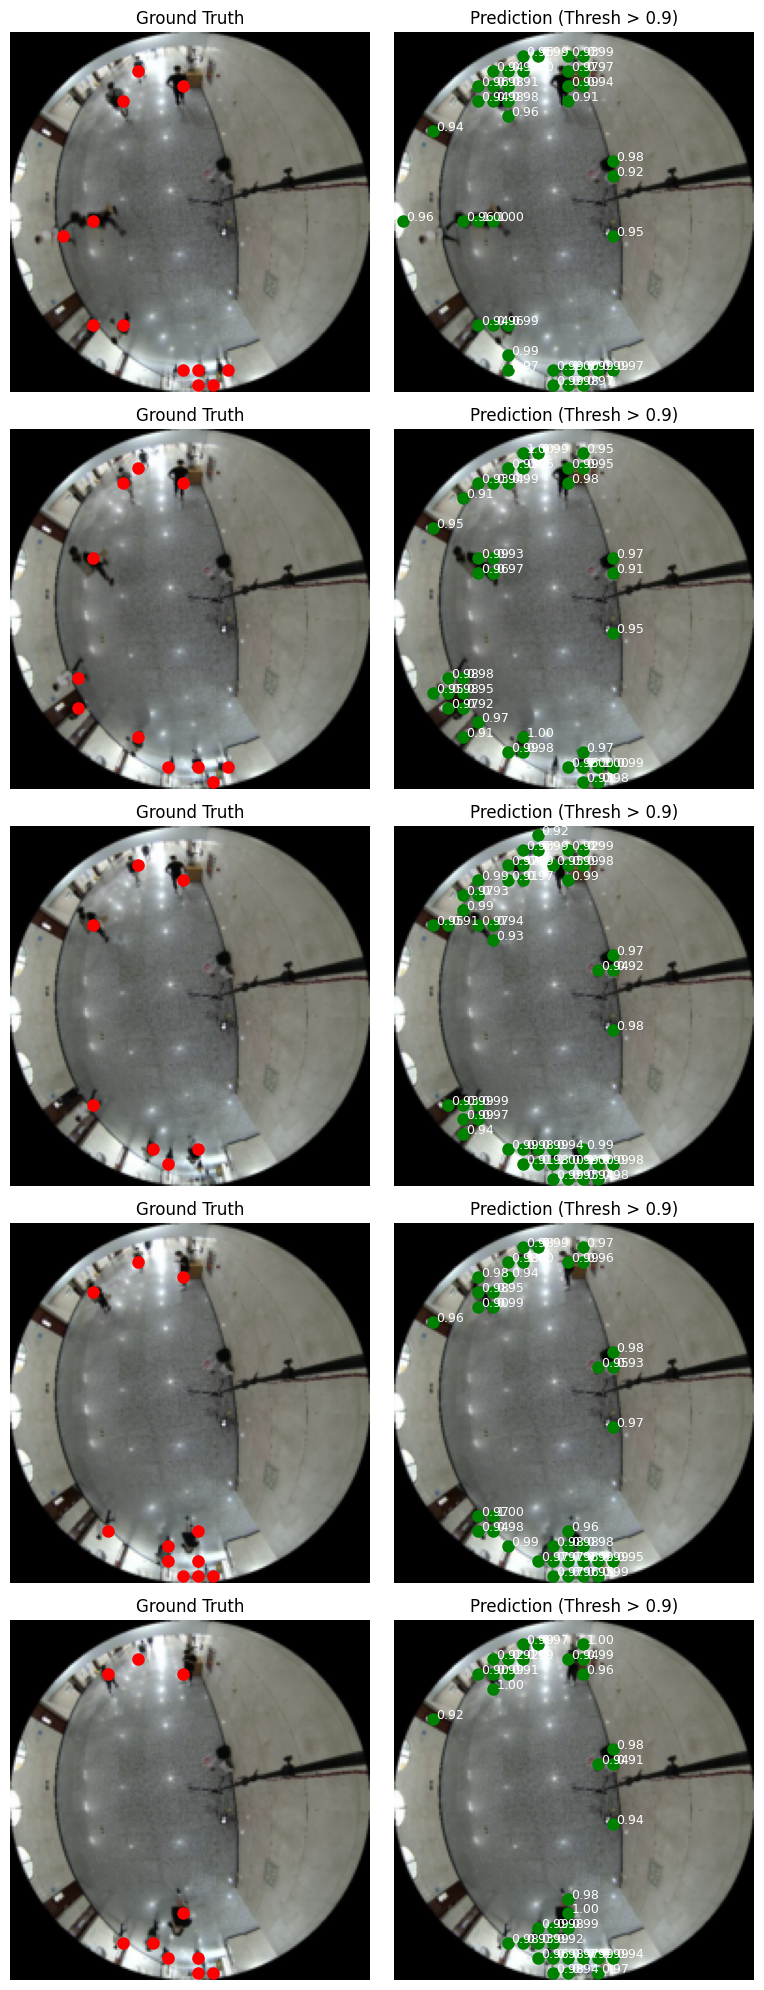

In [31]:
import matplotlib.pyplot as plt
import torch.nn.functional as F

def visualize_fomo_predictions(model, dataloader, device, threshold=0.5, num_samples=4):
    model.eval()

    images, targets = next(iter(dataloader))
    images = images.to(device)
    targets = targets.to(device)

    with torch.no_grad():
        logits = model(images)
        probabilities = F.softmax(logits, dim=1)

    person_probs = probabilities[:, 1, :, :]

    images = images.cpu()
    targets = targets.cpu()
    person_probs = person_probs.cpu()

    fig, axes = plt.subplots(num_samples, 2, figsize=(8, 4 * num_samples))

    for i in range(min(num_samples, len(images))):
        img_display = images[i].permute(1, 2, 0).numpy()
        img_display = (img_display * 0.5) + 0.5
        img_display = np.clip(img_display, 0, 1)

        ax_true = axes[i, 0] if num_samples > 1 else axes[0]
        ax_true.imshow(img_display)
        ax_true.set_title("Ground Truth")
        ax_true.axis('off')

        true_y, true_x = torch.where(targets[i] == 1)

        grid_size = 24
        input_size = 192
        scale = input_size / grid_size

        for ty, tx in zip(true_y, true_x):
            ax_true.plot((tx + 0.5) * scale, (ty + 0.5) * scale, 'ro', markersize=8)

        ax_pred = axes[i, 1] if num_samples > 1 else axes[1]
        ax_pred.imshow(img_display)
        ax_pred.set_title(f"Prediction (Thresh > {threshold})")
        ax_pred.axis('off')

        pred_y, pred_x = torch.where(person_probs[i] > threshold)

        for py, px in zip(pred_y, pred_x):
            prob_score = person_probs[i, py, px].item()
            ax_pred.plot((px + 0.5) * scale, (py + 0.5) * scale, 'go', markersize=8)
            ax_pred.text((px + 0.5) * scale + 2, (py + 0.5) * scale, f"{prob_score:.2f}", color='white', fontsize=9)

    plt.tight_layout()
    plt.show()

visualize_fomo_predictions(model, val_loader, device, threshold=0.90, num_samples=5)

In [34]:
# https://github.com/google-ai-edge/litert-torch
!pip install -q litert_torch

# https://github.com/google-ai-edge/ai-edge-quantizer
# specific post quantize trainer for litert models
!pip install -q ai-edge-quantizer-nightly

# For Ethos NPUs
!pip install -q ethos-u-vela

In [38]:
!pip freeze

absl-py==1.4.0
accelerate==1.13.0
access==1.1.10.post3
affine==2.4.0
ai-edge-litert==2.1.5
ai-edge-litert-nightly==2.2.0.dev20260530
ai-edge-quantizer==0.7.0
ai-edge-quantizer-nightly==0.8.0.dev20260531
aiofiles==24.1.0
aiohappyeyeballs==2.6.2
aiohttp==3.13.5
aiosignal==1.4.0
aiosqlite==0.22.1
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.11.2
alembic==1.18.4
altair==5.5.0
annotated-doc==0.0.4
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.13.0
anywidget==0.9.21
apsw==3.53.1.0
apswutils==0.1.2
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
array_record==0.8.3
arrow==1.4.0
arviz==0.22.0
astropy==7.2.0
astropy-iers-data==0.2026.5.18.1.11.28
astunparse==1.6.3
atpublic==5.1
attrs==26.1.0
audioread==3.1.0
Authlib==1.7.2
autograd==1.8.0
babel==2.18.0
backcall==0.2.0
backports.strenum==1.2.8
beartype==0.22.9
beautifulsoup4==4.13.5
betterproto==2.0.0b6
bigframes==2.40.0
bigquery-magics==0.14.0
bleach==6.3.0
blinker==1.9.0
blis==1.3.3
blobfile==3.2.0
blosc2=

In [35]:
import litert_torch
import torch

# PyTorch model to LiteRT FP32

# Move the model to CPU and set to evaluation mode
model.cpu()
model.eval()

# Create a dummy input matching your network's expected input dimensions
# (batch_size, channels, height, width) -> (1, 3, 192, 192) based on your dataset builder
sample_input = torch.randn(1, 3, 192, 192)

# Convert and export the flatbuffer
edge_model = litert_torch.convert(model, (sample_input,))
edge_model.export("librefomo_fp32.tflite")

print("Saved unquantized model as: librefomo_fp32.tflite")

(00:00) [START] LiteRT-Torch Convert

(00:00) [START] LiteRT-Torch Convert > Torch Export: serving_default

(00:01) [START] LiteRT-Torch Convert > Torch Export: serving_default > ExportedProgram Run Decompositions

/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


(00:02) [ DONE] LiteRT-Torch Convert > Torch Export: serving_default > ExportedProgram Run Decompositions (+00:00)

...

(00:08) [ DONE] LiteRT-Torch Convert > Run LiteRT Converter Passes (+00:00)

(00:08) [ DONE] LiteRT-Torch Convert (+00:08)

(00:00) [START] Write Model to librefomo_fp32.tflite

(00:00) [ DONE] Write Model to librefomo_fp32.tflite (+00:00)

Saved unquantized model as: librefomo_fp32.tflite


In [40]:
from ai_edge_quantizer import quantizer
from ai_edge_quantizer import recipe
import numpy as np
from torch.utils.data import DataLoader

# quantize to int8

qt = quantizer.Quantizer("librefomo_fp32.tflite")

calib_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=0)

def get_calibration_dataset(dataloader, num_samples=150):
    """
    Yields representative data formatted for the LiteRT graph.
    """
    count = 0
    for images, _ in dataloader:
        for i in range(images.size(0)):
            if count >= num_samples:
                return

            # TFLite uses a signature-based interface.
            input_tensor = images[i].unsqueeze(0).numpy()
            yield {"args_0": input_tensor}

            count += 1

calibration_data_list = list(get_calibration_dataset(calib_loader, num_samples=150))

calibration_dict = {"serving_default": calibration_data_list}

int8_recipe = recipe.static_wi8_ai8()
qt.load_quantization_recipe(int8_recipe)

print("Calibrating model...")
calib_result = qt.calibrate(calibration_dict)

print("Applying quantization...")
quant_result = qt.quantize(calib_result)

quant_result.export_model("librefomo_int8.tflite")

print("Saved quantized model as: librefomo_int8.tflite")

Step 2: Quantizing to INT8 using AI Edge Quantizer...
Calibrating model...


Applying quantization...
Model name: librefomo_fp32.tflite
Original model size: 106.38 KiB
Quantized model size: 86.55 KiB
Quantization Ratio: 0.81 (1.2x smaller)
Total time: 23.06 ms
Saved quantized model as: librefomo_int8.tflite


In [41]:
!wget https://raw.githubusercontent.com/bencejdanko/Overhead-People-Counting-YOLOXNano-FOMO-Ethos-U55-NPU/refs/heads/main/configs/default_vela.ini

--2026-05-31 18:49:32--  https://raw.githubusercontent.com/bencejdanko/Overhead-People-Counting-YOLOXNano-FOMO-Ethos-U55-NPU/refs/heads/main/configs/default_vela.ini
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 415 [text/plain]
Saving to: ‘default_vela.ini’

default_vela.ini    100%[===================>]     415  --.-KB/s    in 0s      

2026-05-31 18:49:32 (10.2 MB/s) - ‘default_vela.ini’ saved [415/415]



In [42]:
!vela /content/librefomo_int8.tflite \
  --accelerator-config ethos-u55-256 \
  --config /content/default_vela.ini \
  --memory-mode Shared_Sram \
  --system-config Ethos_U55_High_End_Embedded \
  --output-dir vela_output \
  --optimise Performance



Network summary for librefomo_int8
Accelerator configuration               Ethos_U55_256
System configuration             Ethos_U55_High_End_Embedded
Memory mode                               Shared_Sram
Accelerator clock                                 200 MHz
Design peak SRAM bandwidth                       1.49 GB/s
Design peak Off-chip Flash bandwidth             0.19 GB/s

Total SRAM used                                577.97 KiB
Total Off-chip Flash used                       25.70 KiB

CPU operators = 0 (0.0%)
NPU operators = 30 (100.0%)

Average SRAM bandwidth                           1.18 GB/s
Input   SRAM bandwidth                           2.94 MB/batch
Weight  SRAM bandwidth                           0.27 MB/batch
Output  SRAM bandwidth                           2.36 MB/batch
Total   SRAM bandwidth                           5.71 MB/batch
Total   SRAM bandwidth            per input      5.71 MB/inference (batch size 1)

Average Off-chip Flash bandwidth                 0.01